## Problem 2 (14 points + 2 bonus): DLL & Multipath

**Goal of this problem**: In the lectures, we discussed how the Delay Lock Loop (DLL) tracks the GPS signal and the presence of multipath errors.
In this problem, students will explore how a multipath impacts the DLL in more depth.

When analyzing the DLL discriminator and tracking performance, we often consider an "ideal" auto-correlation peak.
Recall our ideal correlation peak:

<img src="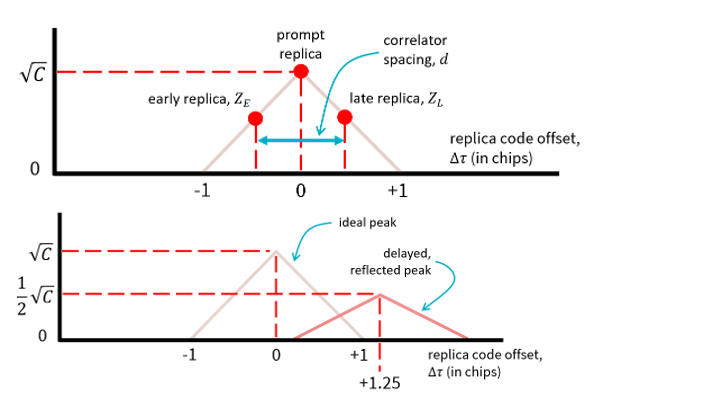
">

Figure 2.1: Depiction of ideal auto-correlation function.
Correlator spacing $d$ defines the spacing (in chips) between the early and the late code replicas.
$C$ is our received signal power.

Notice that this ideal auto-correlation peak in Figure 2.1 has a peak value of $\sqrt{C}$ at a delay of 0 chips, and correlation values of $0$ at any delay $\Delta \tau$ which goes beyond $\pm 1$ chips, i.e. for all delays such that $|\Delta \tau| \geq 1$ chips.
Also, note that the correlation spacing between the early and late replica is defined as $d$ (in chips).

### 2.1 Ideal Autocorrelation [2 points]

Write a function `ideal_autocorr(dt)` which takes in any code offset `dt` (in chips) and outputs the corresponding ideal auto-correlation value, as depicted in Figure 2.1.
You can consider $C=1$, such that the correlation peak height is $+1$.

Using your function, plot the ideal auto-correlation over a range of $\pm 3$ chips offset (i.e., $x$-axis spans $\pm 3$ chips).
Validate that it looks like the plot in Figure 2.1 when `dt` (i.e., $\Delta \tau$) equals zero.
For all plots, ensure that your axes are labeled and include grid lines.

*Hint:* We are *not* considering the auto-correlation sidepeaks in this problem, so you *do not* need to generate the PRN sequence.

***ANSWER***

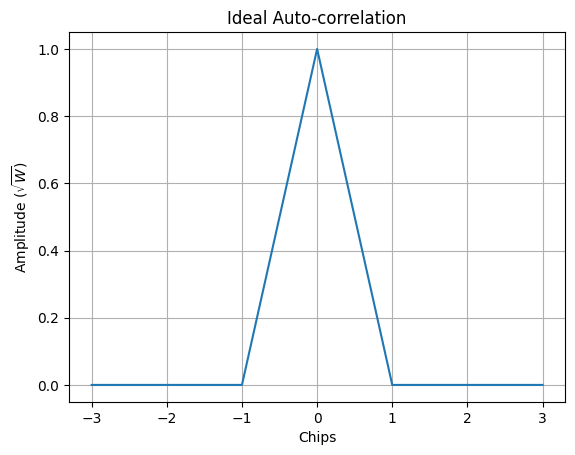

In [146]:
import numpy as np
import matplotlib.pyplot as plt


# Lecture 11
def eval_ideal_autocorr(dt, center = 0):
  # Left side: x - dt + 1
  # Right side: -x + dt + 1

    z = np.zeros_like(dt)

    z = np.where(np.abs(dt - center) < 1, 1 - np.abs(dt-center), 0)

    return z


dt = np.linspace(-3, 3, 301)
z1 = eval_ideal_autocorr(dt, 0.5)
z2 = eval_ideal_autocorr(dt, -0.5)
z = eval_ideal_autocorr(dt)

plt.xlabel("Chips")
plt.ylabel(r"Amplitude ($\sqrt{W}$)")
plt.title("Ideal Auto-correlation")
plt.plot(dt, z)
plt.grid()

In [147]:
# *** DO NOT MODIFY THE CODE BELOW ***
print("@P2.1\n", *np.round(z, 2))

@P2.1
 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.02 0.04 0.06 0.08 0.1 0.12 0.14 0.16 0.18 0.2 0.22 0.24 0.26 0.28 0.3 0.32 0.34 0.36 0.38 0.4 0.42 0.44 0.46 0.48 0.5 0.52 0.54 0.56 0.58 0.6 0.62 0.64 0.66 0.68 0.7 0.72 0.74 0.76 0.78 0.8 0.82 0.84 0.86 0.88 0.9 0.92 0.94 0.96 0.98 1.0 0.98 0.96 0.94 0.92 0.9 0.88 0.86 0.84 0.82 0.8 0.78 0.76 0.74 0.72 0.7 0.68 0.66 0.64 0.62 0.6 0.58 0.56 0.54 0.52 0.5 0.48 0.46 0.44 0.42 0.4 0.38 0.36 0.34 0.32 0.3 0.28 0.26 0.24 0.22 0.2 0.18 0.16 0.14 0.12 0.1 0.08 0.06 0.04 0.02 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0

### 2.2 DLL Discriminator [2 points]

Now that we have our ideal autocorrelation peak, we can also build the early-minus-late DLL discriminator from lecture 10 and Problem 1.
Specifically, we will start with a correlator spacing of $d=1$ chip.
This means the early replica is $0.5$ chips earlier than the prompt replica, and the late replica is $0.5$ chips later than the prompt replica.

Plot the DLL discriminator (i.e., $Z_E - Z_L$) output for a correlator spacing of $d=1$ chip as a function of the code delay over a range of $\pm 3$ chips offset.
Use your function from part (1) to create this discriminator output curve, and ensure your plot matches the discriminator plot we observed in lecture 10 and Problem 1.

*Hint 1:* You can get $Z_E$ and $Z_L$ using your `ideal_autocorr(dt)` function. You just need to shift the input by $\pm0.5$ chips depending on $Z_E$ and $Z_L$.

*Hint 2:* The early replica is highest when the prompt replica is at $0.5$ chips. The late replica is highest when the prompt replica is at $-0.5$ chips.

*Hint 3:* In the *ideal case*, $N_E = N_L = 0$.

*Hint 4:* Can you identify the $\pm \frac{T_C}{2}$ peaks of the discriminator? Does the magnitude of the peak match Figure 2 in Problem 1?

***ANSWER***

[Plot the ideal DLL discriminator for d=1 chip.]

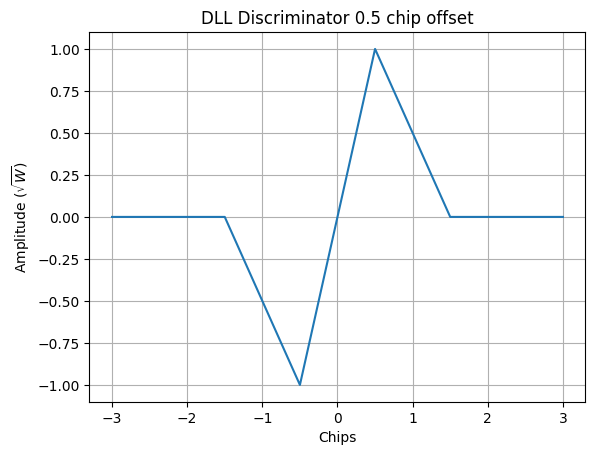

In [148]:
dt = np.linspace(-3, 3, 301)
ze = eval_ideal_autocorr(dt, 0.5)
zl = eval_ideal_autocorr(dt, -0.5)
ze_zl = ze-zl


plt.xlabel("Chips")
plt.ylabel(r"Amplitude ($\sqrt{W}$)")
plt.title("DLL Discriminator 0.5 chip offset")
plt.plot(dt, ze_zl)
plt.grid()

# print(ze)
# print(zl)

In [149]:
# *** DO NOT MODIFY THE CODE BELOW ***
print("@P2.2\n", *np.round(ze_zl, 2))

@P2.2
 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 -0.02 -0.04 -0.06 -0.08 -0.1 -0.12 -0.14 -0.16 -0.18 -0.2 -0.22 -0.24 -0.26 -0.28 -0.3 -0.32 -0.34 -0.36 -0.38 -0.4 -0.42 -0.44 -0.46 -0.48 -0.5 -0.52 -0.54 -0.56 -0.58 -0.6 -0.62 -0.64 -0.66 -0.68 -0.7 -0.72 -0.74 -0.76 -0.78 -0.8 -0.82 -0.84 -0.86 -0.88 -0.9 -0.92 -0.94 -0.96 -0.98 -1.0 -0.96 -0.92 -0.88 -0.84 -0.8 -0.76 -0.72 -0.68 -0.64 -0.6 -0.56 -0.52 -0.48 -0.44 -0.4 -0.36 -0.32 -0.28 -0.24 -0.2 -0.16 -0.12 -0.08 -0.04 0.0 0.04 0.08 0.12 0.16 0.2 0.24 0.28 0.32 0.36 0.4 0.44 0.48 0.52 0.56 0.6 0.64 0.68 0.72 0.76 0.8 0.84 0.88 0.92 0.96 1.0 0.98 0.96 0.94 0.92 0.9 0.88 0.86 0.84 0.82 0.8 0.78 0.76 0.74 0.72 0.7 0.68 0.66 0.64 0.62 0.6 0.58 0.56 0.54 0.52 0.5 0.48 0.46 0.44 

### 2.3 Different Spacings [2 points]
Repeat part (2) for $d=0.5$ chips.
Overlay this DLL discriminator on the DLL discriminator from part (2).

Briefly comment on why the shape is different for a tighter correlator spacing using what you know about the ideal auto-correlation function.

***ANSWER***

[Plot the DLL discriminators for d=1 and d=0.5 chips on the same plot and discuss the differences.]

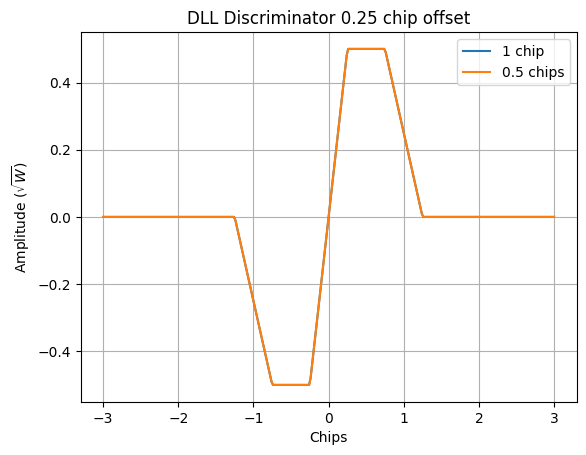

In [150]:
ze = eval_ideal_autocorr(dt, 0.25)
zl = eval_ideal_autocorr(dt, -0.25)
ze_zl = ze-zl

plt.xlabel("Chips")
plt.ylabel(r"Amplitude ($\sqrt{W}$)")
plt.title("DLL Discriminator 0.25 chip offset")
plt.plot(dt, ze_zl, label="1 chip")
plt.plot(dt, ze_zl_05, label="0.5 chips")
plt.legend()
plt.grid()

# print(ze)
# print(zl)

We want ZE and ZL to be symmetric on both sides of the autocorrelation triangle for our code tracking error to be 0. Therefore, we take the difference in the two distributions. Specifically, we look at the extrema of the graph. If the dt offset is smaller, then the peaks are smaller because the difference between ZE and ZL is smaller.

In [151]:
# *** DO NOT MODIFY THE CODE BELOW ***
print("@P2.3\n", *np.round(ze_zl, 2))

@P2.3
 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 -0.01 -0.03 -0.05 -0.07 -0.09 -0.11 -0.13 -0.15 -0.17 -0.19 -0.21 -0.23 -0.25 -0.27 -0.29 -0.31 -0.33 -0.35 -0.37 -0.39 -0.41 -0.43 -0.45 -0.47 -0.49 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.48 -0.44 -0.4 -0.36 -0.32 -0.28 -0.24 -0.2 -0.16 -0.12 -0.08 -0.04 0.0 0.04 0.08 0.12 0.16 0.2 0.24 0.28 0.32 0.36 0.4 0.44 0.48 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.49 0.47 0.45 0.43 0.41 0.39 0.37 0.35 0.33 0.31 0.29 0.27 0.25 0.23 0.21 0.19 0.17 0.15 0.13 0.11 0.09 0.07 0.05 0.03 0.01 0.0 0.0 0

### 2.4 Correlation With Multipath [2 points]
    
Let us consider a simulated multipath scenario and see what happens to our DLL discriminator outputs.
Multipath occurs when we have a secondary, delayed peak in addition to the main correlation peak.
Generally, the second peak has a weaker received power.
But, the second peak could have a positive or negative sign based on the nature of the reflection and the user antenna.
The positive case is akin to constructive interference, and the negative case is akin to destructive interference.
For the next few questions, let us consider the following multipath scenario, where the delayed peak has a relative delay of 1.25 chips and has half the correlation amplitude as the ideal peak.
The 1.25 chips delay is roughly $366$ m for the GPS L1 C/A 1.023 MHz chipping rate.

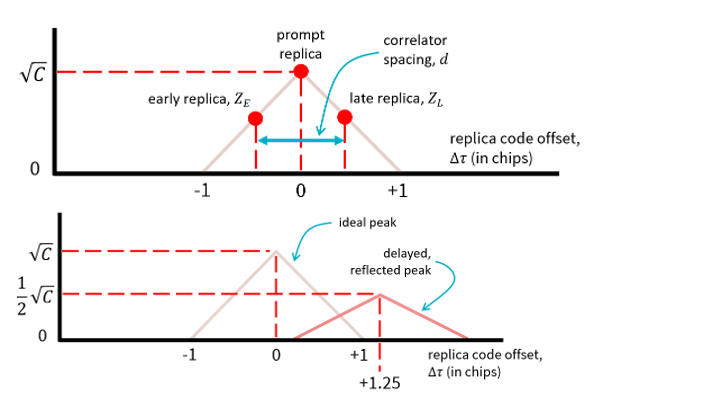

Figure 2.2: Depiction of auto-correlation function in a multipath scenario. The tan curve represents the ideal peak, while the light red curve represents the delayed, reflected peak. Note that the receiver observes the *summation* of these two correlation peaks.

In the presence of multipath, the resulting correlation observed at the receiver (before reaching the DLL) is the *summation* of the two correlation peaks, thereby distorting the resulting DLL discriminator output curve.

Let us model the distorted auto-correlation for this multipath scenario.
Create a function called `eval_multipath_autocorr(dt)` which takes in any code offset `dt` (in chips) and outputs the resulting, distorted correlation peak caused by the secondary reflected signal in Figure 2.2.

Using your function and your function from part (1), plot the following *on the same plot*:
* Ideal auto-correlation peak
* Secondary, delayed peak
* Combined distorted auto-correlation

***ANSWER***

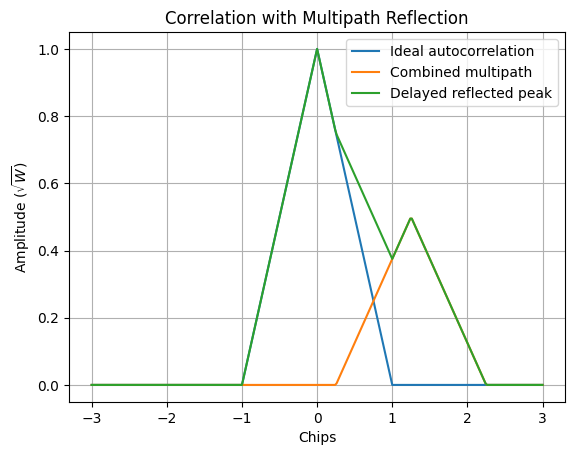

In [152]:
def eval_multipath_autocorr(dt, amplitude, delay):
    # TODO: Implement
    return eval_ideal_autocorr(dt, delay) * amplitude

z_ideal = eval_ideal_autocorr(dt)
z_multipath = eval_multipath_autocorr(dt, 0.5, 1.25)
z_combined = z + z_multipath # TODO: Compute

plt.xlabel("Chips")
plt.ylabel(r"Amplitude ($\sqrt{W}$)")
plt.title("Correlation with Multipath Reflection")
plt.plot(dt, z, label="Ideal autocorrelation")
plt.plot(dt, z_multipath, label="Combined multipath")
plt.plot(dt, z_combined, label="Delayed reflected peak")
plt.grid()
plt.legend()
plt.show()

When a smaller delayed peak is introduced, this causes ZL to be perceived as larger than it actually is (since the reflected peak is also late). Even if ZE and ZL are equal, this does not cause them to be perceived as such.

In [153]:
# *** DO NOT MODIFY THE CODE BELOW ***
print("@P2.4\n", *np.round(z_combined, 2))

@P2.4
 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.02 0.04 0.06 0.08 0.1 0.12 0.14 0.16 0.18 0.2 0.22 0.24 0.26 0.28 0.3 0.32 0.34 0.36 0.38 0.4 0.42 0.44 0.46 0.48 0.5 0.52 0.54 0.56 0.58 0.6 0.62 0.64 0.66 0.68 0.7 0.72 0.74 0.76 0.78 0.8 0.82 0.84 0.86 0.88 0.9 0.92 0.94 0.96 0.98 1.0 0.98 0.96 0.94 0.92 0.9 0.88 0.86 0.84 0.82 0.8 0.78 0.76 0.74 0.73 0.72 0.71 0.7 0.7 0.68 0.68 0.66 0.66 0.64 0.64 0.62 0.62 0.6 0.6 0.58 0.57 0.56 0.55 0.54 0.53 0.52 0.51 0.5 0.49 0.48 0.47 0.46 0.46 0.45 0.44 0.43 0.42 0.4 0.4 0.38 0.38 0.39 0.4 0.41 0.42 0.42 0.44 0.44 0.46 0.46 0.48 0.48 0.5 0.5 0.48 0.48 0.46 0.46 0.44 0.44 0.42 0.42 0.4 0.

### 2.5 DLL Discriminator With Multipath [4 points]
How would our DLL handle this distorted auto-correlation from multipath?
Similar to part (3), plot the DLL discriminator function output for correlator spacings of $d=0.5$\~chips and $d=1$\~chip as a function of the code delay on the same plot.
    
Create a second plot that is zoomed in on the zero-crossing of the discriminator curves (near $\Delta \tau=0$ chips).
    
*Note:* This discrimination curve looks quite different from problem 1 over a $\pm3$ chips offset, but *resembles* problem 1 near the true zero-crossing.

*Note:* Recall that the multipath delay was 1.25 chips away or 366 m delay.
    Even though the delay is quite physically long, it can still noticeably distort our DLL tracking and pseudorange measurement.

***ANSWER***

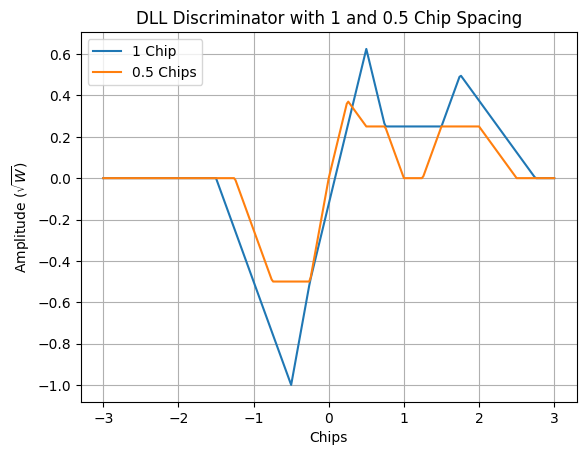

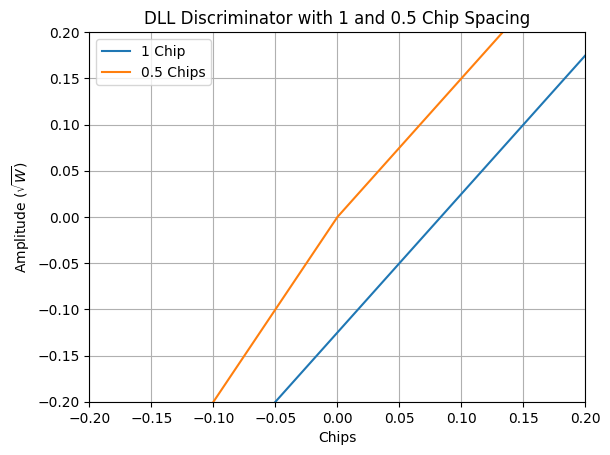

In [154]:
def dll_discriminator(center):
  return eval_ideal_autocorr(dt, center) + eval_multipath_autocorr(dt, 0.5, center + 1.25)

ze_zl_1chip = dll_discriminator(0.5) - dll_discriminator(-0.5)  # TODO: Compute
ze_zl_05chip = dll_discriminator(0.25) - dll_discriminator(-0.25)  # TODO: Compute

plt.xlabel("Chips")
plt.ylabel(r"Amplitude ($\sqrt{W}$)")
plt.title("DLL Discriminator with 1 and 0.5 Chip Spacing")
plt.plot(dt, ze_zl_1chip, label="1 Chip")
plt.plot(dt, ze_zl_05chip, label="0.5 Chips")
plt.grid()
plt.legend()
plt.show()

plt.xlabel("Chips")
plt.ylabel(r"Amplitude ($\sqrt{W}$)")
plt.title("DLL Discriminator with 1 and 0.5 Chip Spacing")
plt.plot(dt, ze_zl_1chip, label="1 Chip")
plt.plot(dt, ze_zl_05chip, label="0.5 Chips")
plt.xlim(-0.2, 0.2)
plt.ylim(-0.2, 0.2)
plt.grid()
plt.legend()
plt.show()




In [155]:
dt_small = dt[(dt < 0.2) & (dt >= -0.2)]
ze_zl_05chip_shaved = ze_zl_05chip[(dt < 0.2) & (dt >= -0.2)]
ze_zl_1chip_shaved = ze_zl_1chip[(dt < 0.2) & (dt >= -0.2)]

def find_x_int_pos_slope(x, y):
  """Based on similar triangles"""

  y_low = y[y<=0][-1]
  y_high = y[y>=0][0]
  x_low = x[y<=0][-1]
  x_high = x[y>=0][0]

  if x_high == x_low:
    return x_high

  dx = x_high-x_low
  dy = y_high-y_low
  return x_low + dx - (dx * y_high/dy)

# y intercept should be in the middle
n = len(dt)

print(f"Y-intercept of 0.5 chips: {ze_zl_05chip[n//2]}")
print(f"Y-intercept of 1 chips: {ze_zl_1chip[n//2]}")
print(f"X-intercept of 0.5 chips: {find_x_int_pos_slope(dt_small, ze_zl_05chip_shaved)}")
print(f"X-intercept of 1 chips: {find_x_int_pos_slope(dt_small, ze_zl_1chip_shaved)}")

Y-intercept of 0.5 chips: 0.0
Y-intercept of 1 chips: -0.125
X-intercept of 0.5 chips: 0.0
X-intercept of 1 chips: 0.08333333333333333


In [156]:
# *** DO NOT MODIFY THE CODE BELOW ***
print("@P2.5\n", *np.round(ze_zl_1chip, 2), "\n", *np.round(ze_zl_05chip, 2))

@P2.5
 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 -0.02 -0.04 -0.06 -0.08 -0.1 -0.12 -0.14 -0.16 -0.18 -0.2 -0.22 -0.24 -0.26 -0.28 -0.3 -0.32 -0.34 -0.36 -0.38 -0.4 -0.42 -0.44 -0.46 -0.48 -0.5 -0.52 -0.54 -0.56 -0.58 -0.6 -0.62 -0.64 -0.66 -0.68 -0.7 -0.72 -0.74 -0.76 -0.78 -0.8 -0.82 -0.84 -0.86 -0.88 -0.9 -0.92 -0.94 -0.96 -0.98 -1.0 -0.96 -0.92 -0.88 -0.84 -0.8 -0.76 -0.72 -0.68 -0.64 -0.6 -0.56 -0.52 -0.48 -0.45 -0.42 -0.4 -0.37 -0.34 -0.31 -0.28 -0.25 -0.22 -0.19 -0.16 -0.12 -0.09 -0.06 -0.03 -0.0 0.03 0.06 0.09 0.12 0.15 0.18 0.21 0.24 0.27 0.3 0.33 0.36 0.38 0.41 0.44 0.47 0.5 0.53 0.56 0.6 0.62 0.6 0.56 0.53 0.5 0.47 0.44 0.41 0.38 0.35 0.32 0.29 0.26 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25

### 2.6 Induced Biases [2 points]
For which DLL will the multipath peak(s) induce a bias(es) in our pseudorange error?
If so, approximately how much (in meters to a reasonable number of significant figures)?
If not, explain why not.
    
*Note:* This advantage comes at a cost. Indeed, you may have heard the saying that "there's no free lunch" in engineering since our design choices often have a trade-off (although, the same saying rarely applies to engineering college campuses, where free lunches and meals are quite commonplace).
Explore this further in Bonus 2!

***ANSWER***

The pseudorange will be affected by any multipath peaks, but in particular, those that are further apart and more likely to have the reflected peak affect only one of the correlators. When ZE and ZL are closer together, a reflected signal is more likely to affect both at once, but when they are further apart, there is a higher chance that only one is affected.

For the L1 band, the chirp length is about 1 microsecond ($1\times10^{-6} s$), with the speed of light, gives about 300m per chirp. Since 1 chirp is the maximum error in the bias, this 300m error is the upper bound frmom this source, but realistically, it will be fractions of chirps, so for about 0.25 chirps, the error is about 75m.

### Bonus [1 points]
Suppose we already track the ideal peak before encountering multipath.
If the secondary peak is sufficiently delayed from the ideal peak, it will no longer induce any error in our DLL tracking loop.
How much multipath delay (in chips and meters) is sufficient for correlator spacings of $d=$ 0.1, 0.5, or 1~chips?
And, how much better is a smaller correlator spacing versus how much better is the GPS L1 P(Y) military signal?

Specifically, make a table that shows the minimum amount of delay in the reflected signal peak for which our early-minus-late correlator is no longer affected by multipath errors for the GPS L1 C/A versus L1 P(Y) signal. Make this table for $d=0.1$~chips, $d=0.5$~chips, and $d=1$~chip. Which is better?

*Hint:* There should be six data entries in this table, and you do not necessarily need to use any of the code you wrote previously in the problem (i.e., you can do a direct calculation of these entries).

***ANSWER***

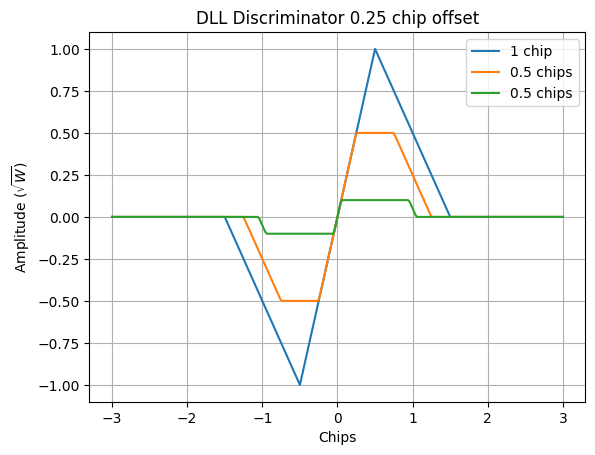

In [157]:
ze = eval_ideal_autocorr(dt, 0.05)
zl = eval_ideal_autocorr(dt, -0.05)
ze_zl_01 = ze-zl

ze = eval_ideal_autocorr(dt, 0.25)
zl = eval_ideal_autocorr(dt, -0.25)
ze_zl_05 = ze-zl

ze = eval_ideal_autocorr(dt, 0.5)
zl = eval_ideal_autocorr(dt, -0.5)
ze_zl_1 = ze-zl

plt.xlabel("Chips")
plt.ylabel(r"Amplitude ($\sqrt{W}$)")
plt.title("DLL Discriminator 0.25 chip offset")
plt.plot(dt, ze_zl_1, label="1 chip")
plt.plot(dt, ze_zl_05, label="0.5 chips")
plt.plot(dt, ze_zl_01, label="0.5 chips")
plt.legend()
plt.grid()

[Compute the minimum delay in chips and meters for the C/A and P(Y) signals for the three different correlator spacings. Justify and discuss your results.]

The reflected peak has to be at least 1 chip away to avoid overlapping with the autocorrelation function peak in general. There also has to be an additional delay for each spacing $d$.. For example, with a difference of 0.1 chirp, the delay has to be an additional 0.05 chirps to prevent it from affecting ZL. That is, the left side of the delayed peak will be outside of the $0.5d$ of ZL.

The pseudorange error is based off of the previously mentioned 300m for C/A signals, and therefore, because the military signal P(Y) is 10 times quicker, this causes its error to be about 30m


| Correlator Spacing | Minimum delay [chips]      | C/A signal [meters] | P(Y) signal [meters] |
| :----------------- | :------------------------- | :------------------ | :------------------- |
| $d = 0.1$ chips    |                1.05           |          315         |           31.5           |
| $d = 0.5$ chips    |                      1.25      |                375     |            37.5          |
| $d = 1$ chip       |             1.5               |    450                 |          45            |

In [158]:
c_a_period = 1/1.023e6 #

m_per_chip = 3e8 * c_a_period


# TODO: Compute minimum delay in chips and meters for the C/A and P(Y) signals for the three different correlator spacings d=0.1, 0.5, 1 chips (in that order)
min_delay_chips = [1.05, 1.25, 1.5]
min_delay_meters_ca = [1.05*m_per_chip, 1.25*m_per_chip, 1.5*m_per_chip]
min_delay_meters_py = [1.05*m_per_chip/10, 1.25*m_per_chip/10, 1.5*m_per_chip/10]

In [159]:
# *** DO NOT MODIFY THE CODE BELOW ***
print(
    "@P2.Bonus1\n",
    *np.round(min_delay_chips, 2),
    *np.round(min_delay_meters_ca, 2),
    *np.round(min_delay_meters_py, 2)
)

@P2.Bonus1
 1.05 1.25 1.5 307.92 366.57 439.88 30.79 36.66 43.99


### Bonus [1 point]
Though we saw an advantage to using the $d=0.5$\~chip early-minus-late discriminator over the $d=1$\~chip one, this benefit comes at a cost.
Compare the two discriminator outputs that you obtained in parts (2) and (3).
Explain one key drawback of using the narrower correlator.
When may you want which correlator spacing?

*Hint:* You may find it helpful to review the lecture 11 slides on how the DLL tracking loop operates (or chapter 12 of the textbook) to answer this question.

***ANSWER***

With smaller chirp differences, if the signal error is very far off of the prompt, then there is a higher chance that both ZE and ZL are not on the main autocorrelation triangle at all. Then, because they are both equal and there is no perceived error, the GPS will not shift its prompt peak.

Narrower early-minus-late distriminators would be preferable in low noise environments.

Wider discriminators are ideal for noisy environments because they are more ideal for wider initial errors, and are more robust to noise in general.